# 基于水色图像的水质评价
随着工业技术的日益提升，人类的生活受得越来越便利。但与此同时，环境污染问题世日造严重。大气、土壤、水质污染是各个工业国家不得不面对的问题。污染需要治理、因此对于污染物的评价与监测十分重要。水产养殖业是我国国民经济的一个要组成部分。在水产港殖的过程中，选择没有污染的水城进行养殖十分重要

本项目使用拍摄的池塘水样图片数据，结合图像切割和特征提取技术，使用决策树算法，对图样的水质进行预测，以辅助生产人员对水质状况进行判断。
# 背景介绍

有经验的从事渔业生产者可通过观察水色变化调控水质，以维持养殖水体生态系统中浮游植物、微生物类、浮游动物等合理的动态平衡。由于这些多是通过经验和肉眼观察进行判断，存在主观性引起的观察性偏倚，使观察结果的可比性、可重复性降低，不易推广应用。当前，数字图像处理技术为计算机监控技术在水产养殖业的应用提供更大的空间。在水质在线监测方面，数字图像处理技术是基于计算机视觉，以专家经验为基础，对池塘水色进行优劣分级，达到对池塘水色的准确快速判别。

# 挖掘目标
结合某地区的多个罗非鱼池塘水样的数据，实现以下目标。
-  对水样图片进行切割，提取水样图片中的特征。
-  基于提取的特征数据，构建水质评价模型。
-  对构建的模型进行评价，评价模型对于水色的识别效率。

# 步骤流程：
## 基本流程介绍
### 为什么要特征提取
通过拍摄水样，采集得到水样图像，而图像数据的维度过大，不容易分析，需要从中提取水样图像的特征，提取反映图像本质的一些关键指标，以达到自动进行图像识别或分类的目的。显然，图像特征提取是图像识别或分类的关键步骤，图像特征提取的效果如何直接影响到图像识别和分类的好坏。
### 提取什么特征？
图像特征主要包括有颜色特征、纹理特征、形状特征、空间关系特征等。与几何特征相比，颜色特征更为稳健，对于物体的大小和方向均不敏感，表现出较强的鲁棒性。本案例中由于水色图像是均匀的，故主要关注颜色特征。颜色特征是一种全局特征,描述了图像或图像区域所对应的景物的表面性质。一般颜色特征是基于像素点的特征，所有属于图像或图像区域的像素都有各自的贡献。在利用图像的颜色信息进行图像处理、识别、分类的研究中，在实现方法上已有大量的研究成果，主要采用颜色处理常用的直方图法和颜色矩方法等。
### 如何进行特征提取？
颜色直方图是最基本的颜色特征表示方法，它反映的是图像中颜色的组成分布，即出现了哪些颜色以及各种颜色出现的概率。其优点在于它能简单描述一幅图像中颜色的全局分布，即不同色彩在整幅图像中所占的比例，特别适用于描述那些难以自动分割的图像和不需要考虑物体空间位置的图像。其缺点在于它无法描述图像中颜色的局部分布及每种色彩所处的空间位置，即无法描述图像中的某一具体的对象或物体。

基于颜色矩提取图像特征的数学基础在于图像中任何的颜色分布均可以用它的矩来表示。根据概率论的理论，随机变量的概率分布可以由其各阶矩唯一的表示和描述。一副图像的色彩分布也可认为是一种概率分布，那么图像可以由其各阶矩来描述。颜色矩包含各个颜色通道的一阶距、二阶矩和三阶矩，对于一副RGB颜色空间的图像，具有R、G和B三个颜色通道，则有9个分量。

颜色直方图产生的特征维数一般大于颜色矩的特征维数，为了避免过多变量影响后续的分类效果，在本案例中选择采用颜色矩来提取水样图像的特征，即建立水样图像与反映该图像特征的数据信息关系，同时由有经验的专家对水样图像根据经验进行分类，建立水样数据信息与水质类别的专家样本库，进而构建分类模型，得到水样图像与水质类别的映射关系，并经过不断调整系数优化模型，最后利用训练好的分类模型，用户就能方便地通过水样图像，自动判别出该水样的水质类别。



### 基于水色图像特征提取的水质评价步骤如下

- 从采集到的原始水样图像中进行选择性抽取形成建模数据。
- 对步骤1形成的数据集进行数据预处理，包括图像切割和颜色矩特征提取。
- 利用步骤2形成的已完成数据预处理的建模数据，划分为训练集与测试集。
- 利用步骤3的训练集构建分类模型。
- 利用步骤4的构建好的分类模型进行水质评价。

### 基于水色图像特征提取的水质评价流程图如下
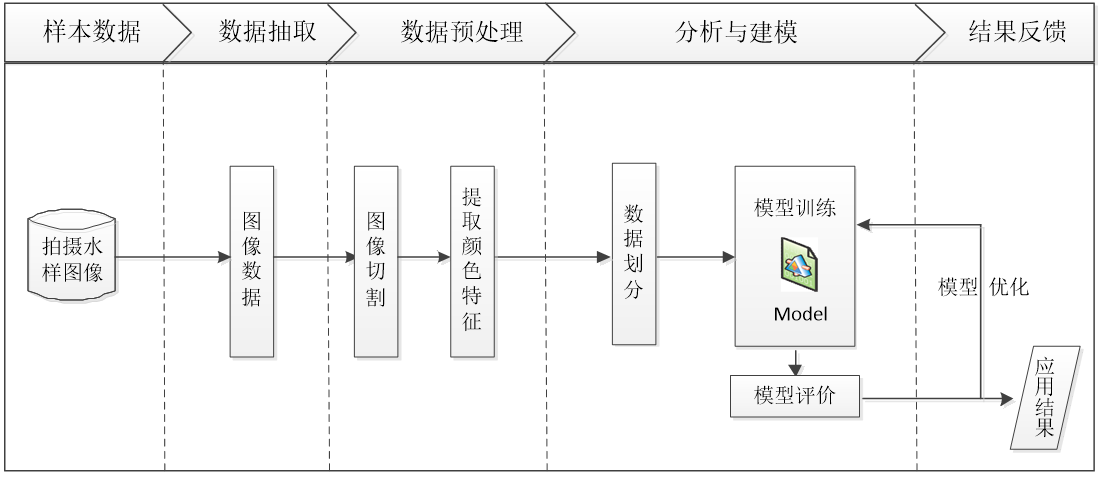

## 数据预处理

In [15]:
# %load  waterquality.py

# 代码9-1

import numpy as np
import os,re
from PIL import Image

### 图片加载（图片相对路径加载）
附件在“demo/data/images/”目录下给出了某地区的多个罗非鱼池塘水样的数据，包含水产专家按水色判断水质分类的数据以及用数码相机按照标准进行水色采集的数据如下表和下图所示，每个水质图片命名规则为“类别-编号.jpg”，如“1_1.jpg”说明当前图片属于第1类的样本。
水色|浅绿色（清水或浊水）|灰蓝色|黄褐色|茶褐色（姜黄、茶褐、红褐、褐中带绿等）|绿色（黄绿、油绿、蓝绿、墨绿、绿中带褐等）
:-----|:-----|:-----|:-----|:-----|:-----
水质类别|1|2|3|4|5|

In [16]:
# 图像切割及特征提取
path = '../../demo/data/images/'  # 图片所在路径

### 图片名称获取

In [17]:
# 自定义获取图片名称函数
def getImgNames(path=path):
    '''
    获取指定路径中所有图片的名称
    :param path: 指定的路径
    :return: 名称列表
    '''
    filenames = os.listdir(path)
    imgNames = []
    for i in filenames:
        if re.findall('^\d_\d+\.jpg$', i) != []:
            imgNames.append(i)
    return imgNames

### 获取三阶颜色矩

In [18]:
# 自定义获取三阶颜色矩函数
def Var(data=None):
    '''
    获取给定像素值矩阵的三阶颜色矩
    :param data: 给定的像素值矩阵
    :return: 对应的三阶颜色矩
    '''
    x = np.mean((data-data.mean())**3)
    return np.sign(x)*abs(x)**(1/3)

### 批处理所有图片进行特征提取

In [19]:
# 批量处理图片数据
imgNames = getImgNames(path=path)  # 获取所有图片名称
n = len(imgNames)        # 图片张数
data = np.zeros([n, 9])  # 用来装样本自变量
labels = np.zeros([n])   # 用来放样本标签

#### 第一步：图像切割
采集到的水样图像包含盛水容器，容器的颜色与水体颜色差异较大，同时水体位于图像中央，为了提取水色的特征，需要提取水样图像中央部分具有代表意义的图像，具体实施方式是提取水样图像中央101×101像素的图像。
采集到的水样图像包含盛水容器，容器的颜色与水体颜色差异较大，同时水体位于图像中央，为了提取水色的特征，需要提取水样图像中央部分具有代表意义的图像，具体实施方式是提取水样图像中央101×101像素的图像。设原始图像 的大小是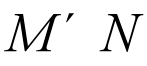，则截取宽从第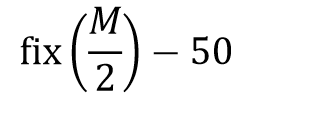个像素点到第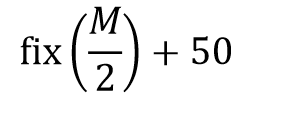个像素点，长从第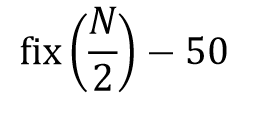个像素点到第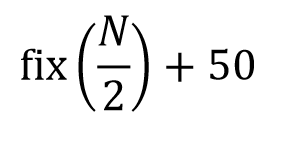个像素点的子图像。


使用Python编程软件进行编程，即可把下图中左边的切割前的水样图像切割并保存到右边的切割后的水样图像。
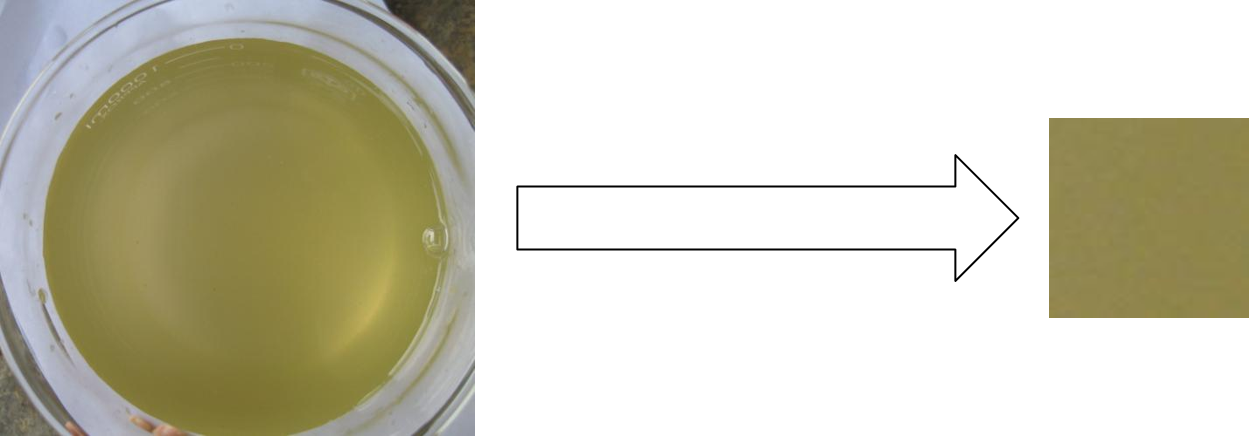
#### 第二步：特征提取
选择采用颜色矩来提取水样图像的特征，下面给出各阶颜色矩的计算公式。

一阶颜色矩

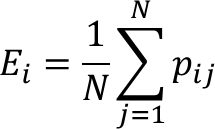

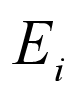是在第i个颜色通道的一阶颜色矩，对于RGB颜色空间的图像，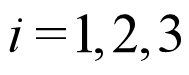， p_ij 是第j个像素的第i个颜色通道的颜色值。


二阶颜色矩

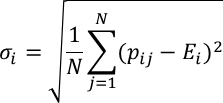

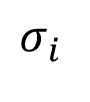是在第i个颜色通道的二阶颜色矩，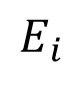是在第i个颜色通道的一阶颜色矩。


三阶颜色矩

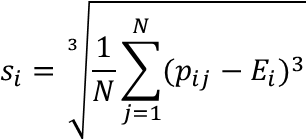

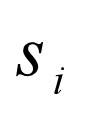是在第i个颜色通道的三阶颜色矩，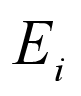是在第i个颜色通道的一阶颜色矩。


In [20]:
for i in range(n):
    img = Image.open(path+imgNames[i])  # 读取图片
    M,N = img.size  # 图片像素的尺寸
    img = img.crop((M/2-50,N/2-50,M/2+50,N/2+50))    # 图片切割
    r,g,b = img.split()     # 将图片分割成三通道
    rd = np.asarray(r)/255  # 转化成数组数据
    gd = np.asarray(g)/255
    bd = np.asarray(b)/255

    data[i,0] = rd.mean()  # 一阶颜色矩
    data[i,1] = gd.mean()
    data[i,2] = bd.mean()

    data[i,3] = rd.std()   # 二阶颜色矩
    data[i,4] = gd.std()
    data[i,5] = bd.std()

    data[i,6] = Var(rd)    # 三阶颜色矩
    data[i,7] = Var(gd)
    data[i,8] = Var(bd)

    labels[i] = imgNames[i][0]  # 样本标签

对切割后的图像提取其颜色矩，作为图像的颜色特征。颜色矩的提取，并且提取每个文件名中的类别和序号，同时针对所有的图片都进行同样的操作，因提取的特征的取值范围差别较大，如果直接输入模型，可能会导致模型精确度下降，因此，在建模之前需要将数据进行标准化。


## 模型构建
### 数据准备，拆分训练集、测试集

采用决策树作为水质评价分类模型，模型的输入包括两部分，一部分是训练样本的输入，另一部分是建模参数的输入。各参数说明如下表所示。

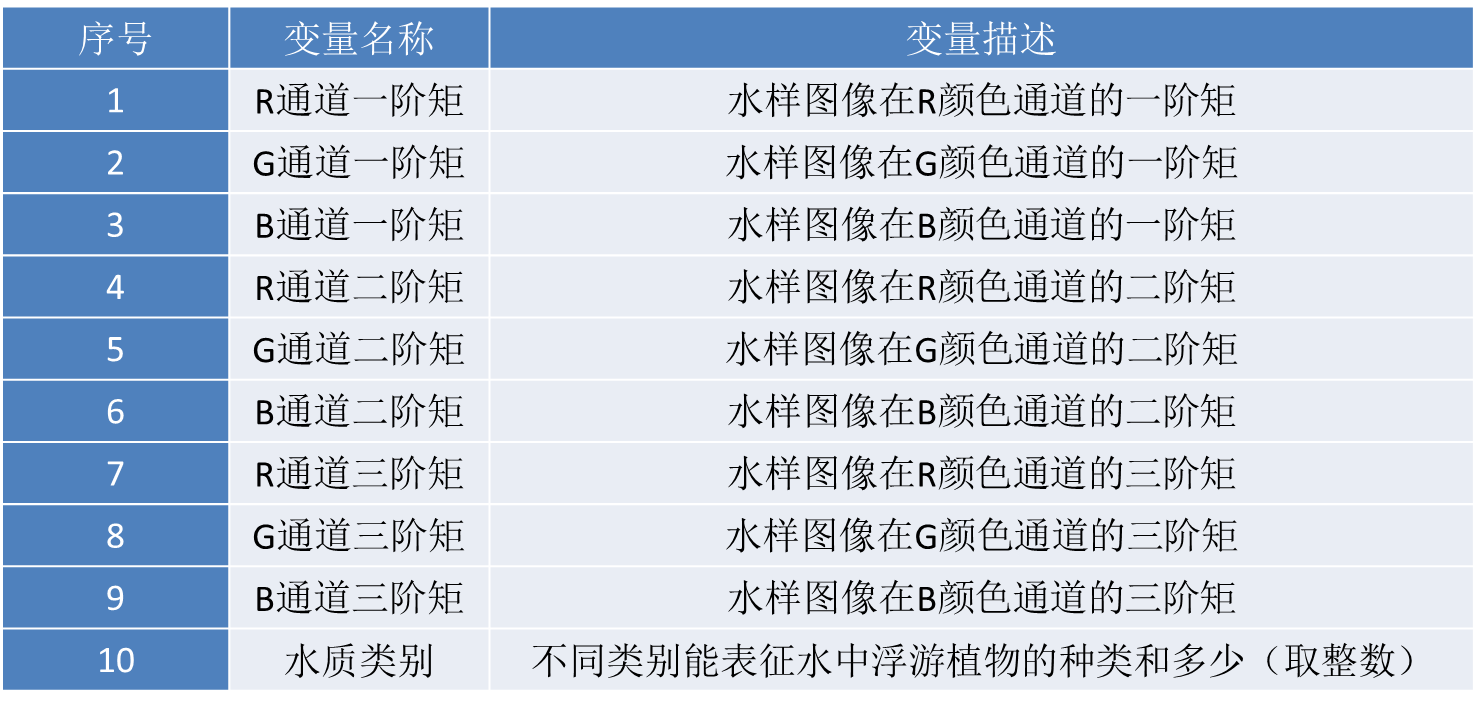


其中1~9均为输入的特征，对标准化后的样本进行抽样，抽取80%作为训练样本，剩下的20%作为测试样本，用于水质评价检验，使用决策树算法构建水质评价模型。

In [21]:
	
# 代码9-2	
	
from sklearn.model_selection import train_test_split
# 数据拆分,训练集、测试集
data_tr,data_te,label_tr,label_te = train_test_split(data,labels,test_size=0.2,
                                                     random_state=10)

### 模型训练，构建决策树算法模型

In [22]:
from sklearn.tree import DecisionTreeClassifier
# 模型训练
model = DecisionTreeClassifier(random_state=5).fit(data_tr, label_tr) 

## 模型评估
### 模型预测

In [23]:
# 代码9-3

# 水质评价
from sklearn.metrics import confusion_matrix
pre_te = model.predict(data_te)

In [24]:
pre_te

array([1., 1., 2., 3., 1., 2., 2., 2., 3., 1., 4., 3., 1., 3., 2., 3., 3.,
       1., 3., 1., 3., 1., 3., 3., 3., 3., 3., 2., 2., 1., 2., 2., 1., 3.,
       3., 4., 3., 2., 4., 3., 4.])

### 混淆矩阵评价

水质评价

取所有测试样本为输入样本，代入已构建好的决策树模型，得到输出结果，即测的水质类型。

水质评价的混淆矩阵如下表所示，分类准确率为70.73%，说明水质评价模型对于新增的水色图像的分类效果较好，可将模型应用到水质自动评价系统，实现水质评价。（注意，由于用随机函数来打乱数据，因此重复试验所得到的结果可能有所不同。）

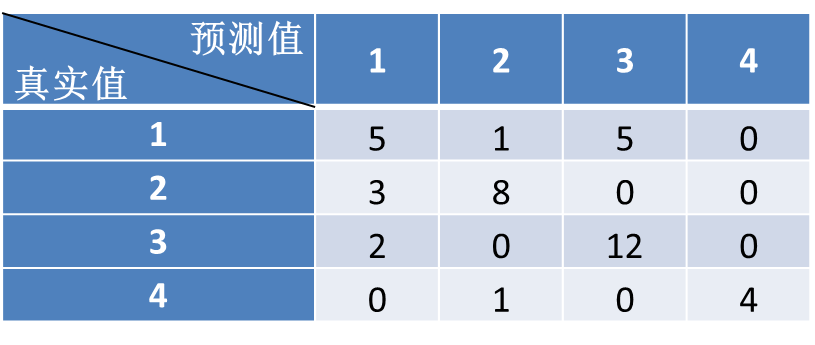

In [25]:
# 混淆矩阵
cm_te = confusion_matrix(label_te,pre_te)
print(cm_te)


[[ 5  1  5  0]
 [ 3  8  0  0]
 [ 2  0 12  0]
 [ 0  1  0  4]]


### 准确率指标评价

In [26]:
from sklearn.metrics import accuracy_score
# 准确率
print(accuracy_score(label_te,pre_te))

0.7073170731707317


根据上述要求，请采用C4.5算法、CART算法或者支持向量机算法重新进行模型构建，评价模型效果并进行相应模型的比较